In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import scipy as sc

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
no_plates_20 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/no_plates_20cm.csv")
plates_20 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/plates_20cm.csv")
no_plates_30 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/no_plates_30cm.csv")
plates_30 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/plates_30cm.csv")

In [53]:
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])  # positions of probes in meters from wave maker
x_prof = x_probe_pos - x_probe_pos[0]  # positions of probes relative to the first probe

In [54]:
f_20 = no_plates_20["frequency"].unique()
f_30 = no_plates_30["frequency"].unique()

D_20 = 0.2
H_20 = 0.15
D_30 = 0.3
H_30 = 0.25

k_20 = []
for f in f_20:
    k_20.append(wave_number_in_theory(f, H_20))
    
k_30 = []
for f in f_30:
    k_30.append(wave_number_in_theory(f, H_30))

In [55]:
a_theory_20 = []
a_weber_20 = []

for k in k_20:
    t, w = spatial_damping_coefficient(k, D_20, H_20)
    a_theory_20.append(t)
    a_weber_20.append(w)

a_theory_30 = []
a_weber_30 = []

for k in k_30:
    t, w = spatial_damping_coefficient(k, D_30, H_30)
    a_theory_30.append(t)
    a_weber_30.append(w)

In [56]:
"""
Subtract the wall-effects from the damping coefficients observed with plates, to get the damping due to the plates alone. 
Then compare this to the theoretical predictions for damping by a thin plate.
"""

plates_20['alpha_plates'] = plates_20['alpha'] - no_plates_20['alpha']
plates_30['alpha_plates'] = plates_30['alpha'] - no_plates_30['alpha']

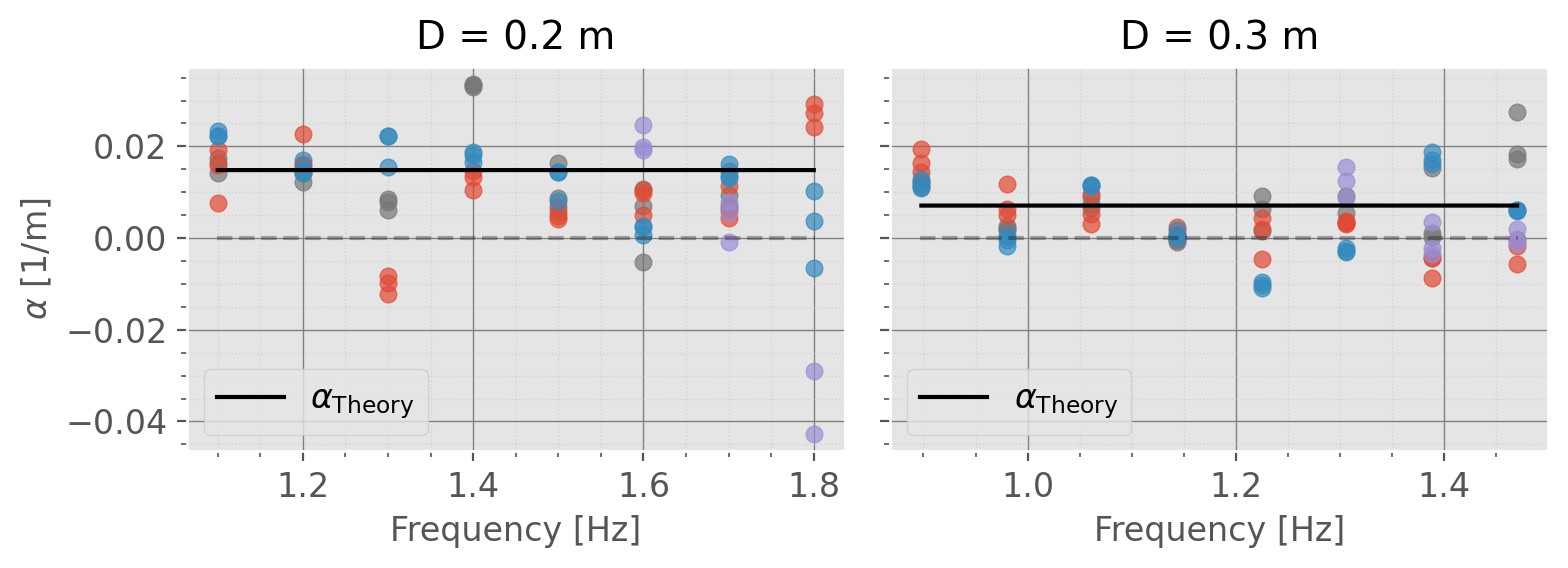

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

level_colors = {
    "low":  "C0",
    "medium":  "C1",
    "medium-high": "C2",
    "high": "C3",
}
ax[0].plot(f_20, np.array(a_theory_20), '-', color='black', label=r'$\alpha_{\text{Theory}}$')
ax[1].plot(f_30, np.array(a_theory_30), '-', color='black', label=r'$\alpha_{\text{Theory}}$')

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["frequency"], sub["alpha_plates"],
               marker='o',
               alpha=0.7,
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["frequency"], sub["alpha_plates"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))

""" ax[0].plot(plates_20['frequency'], plates_20['alpha_plates'], 'o', alpha=0.7, color='C0', label=r'$\alpha_{\text{Obs.}}$')
ax[1].plot(plates_30['frequency'], plates_30['alpha_plates'], 'o', alpha=0.7, color='C1', label=r'$\alpha_{\text{Obs.}}$')"""

ax[0].hlines(0, 1.099, 1.801, colors='k', linestyles='dashed', alpha=0.3)
ax[1].hlines(0, 0.897, 1.471, colors='k', linestyles='dashed', alpha=0.3)

ax[0].set_title('D = 0.2 m')
ax[1].set_title('D = 0.3 m')

ax[0].set_xlabel('Frequency [Hz]')
ax[1].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'$\alpha$ [1/m]')

ax[0].legend(loc='lower left')
ax[1].legend(loc='lower left')

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray') 

plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/alpha_obs_vs_theory.png", dpi=300)

In [58]:
# RMS of the difference between observed and theoretical damping coefficients
rms_20 = []
for idx, f in enumerate(f_20):
    obs = plates_20.loc[plates_20['frequency'] == f, 'alpha_plates'].values
    for val in obs:
        rms_20.append(np.sqrt((val - a_theory_20[idx]) ** 2))
plates_20['rms_alpha'] = rms_20

rms_30 = []
for idx, f in enumerate(f_30):
    obs = plates_30.loc[plates_30['frequency'] == f, 'alpha_plates'].values
    for val in obs:
        rms_30.append(np.sqrt((val - a_theory_30[idx]) ** 2))
plates_30['rms_alpha'] = rms_30

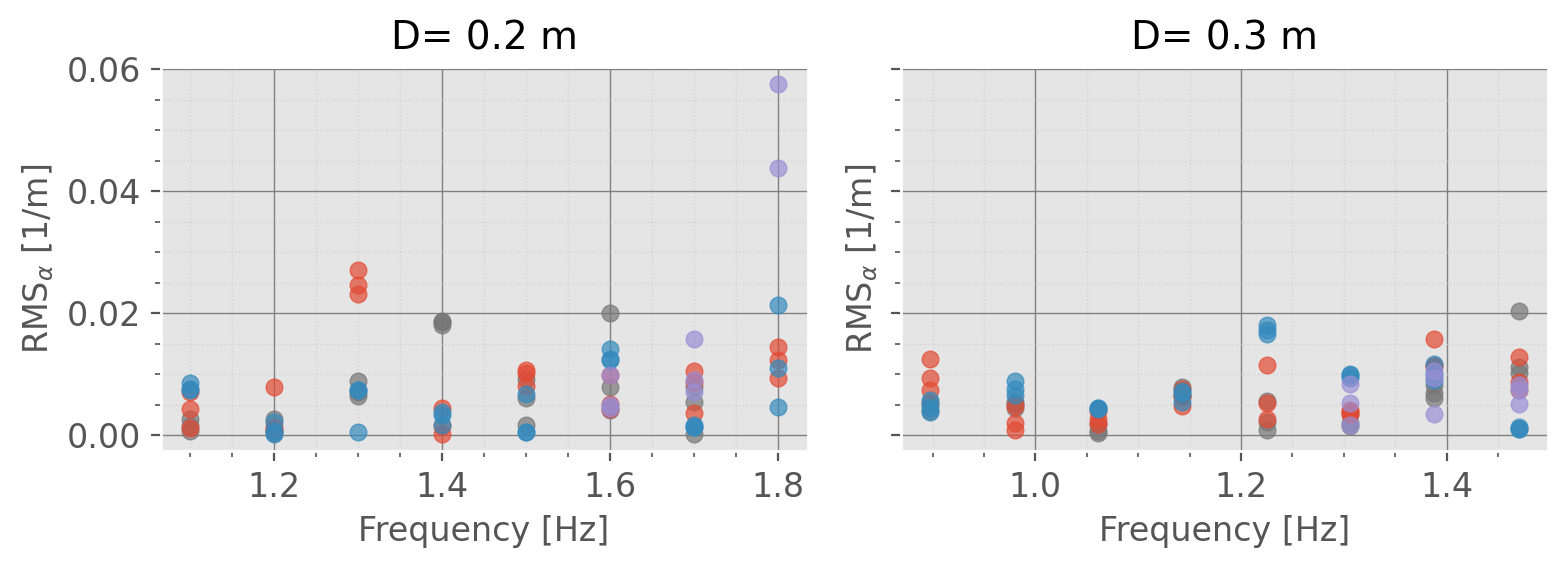

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["frequency"], sub["rms_alpha"],
               marker='o',
               alpha=0.7,
               label=f'{level}',
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["frequency"], sub["rms_alpha"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))
    
ax[0].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'RMS$_{\alpha}$ [1/m]')
ax[0].set_title("D= 0.2 m")
ax[1].set_xlabel('Frequency [Hz]')
ax[1].set_ylabel(r'RMS$_{\alpha}$ [1/m]')
ax[1].set_title("D= 0.3 m")

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray') 
plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/rms_alpha_obs_vs_theory.png", dpi=300)

In [60]:
R_theory_20_eq39 = []
R_theory_30_eq39 = []

for k in k_20:
    R_theory_20_eq39.append(robin_parameter_eq_39(H=H_20, a=a_theory_20[k_20.index(k)], k=k))

for k in k_30:
    R_theory_30_eq39.append(robin_parameter_eq_39(H=H_30, a=a_theory_30[k_30.index(k)], k=k))

In [61]:
R_theory_20_eq28 = []
R_theory_30_eq28 = []

for k, f in zip(k_20, f_20):
    R_theory_20_eq28.append(robin_parameter_eq_28(f=f, k=k, a=a_theory_20[k_20.index(k)], H=H_20))

for k, f in zip(k_30, f_30):
    R_theory_30_eq28.append(robin_parameter_eq_28(f=f, k=k, a=a_theory_30[k_30.index(k)], H=H_30))

In [62]:
"""
Subtract the wall-effects from the damping coefficients observed with plates, to get the damping due to the plates alone. 
Then compare this to the theoretical predictions for damping by a thin plate.
"""
plates_20['R_plates'] = plates_20['R'] - no_plates_20['R']
plates_30['R_plates'] = plates_30['R'] - no_plates_30['R']

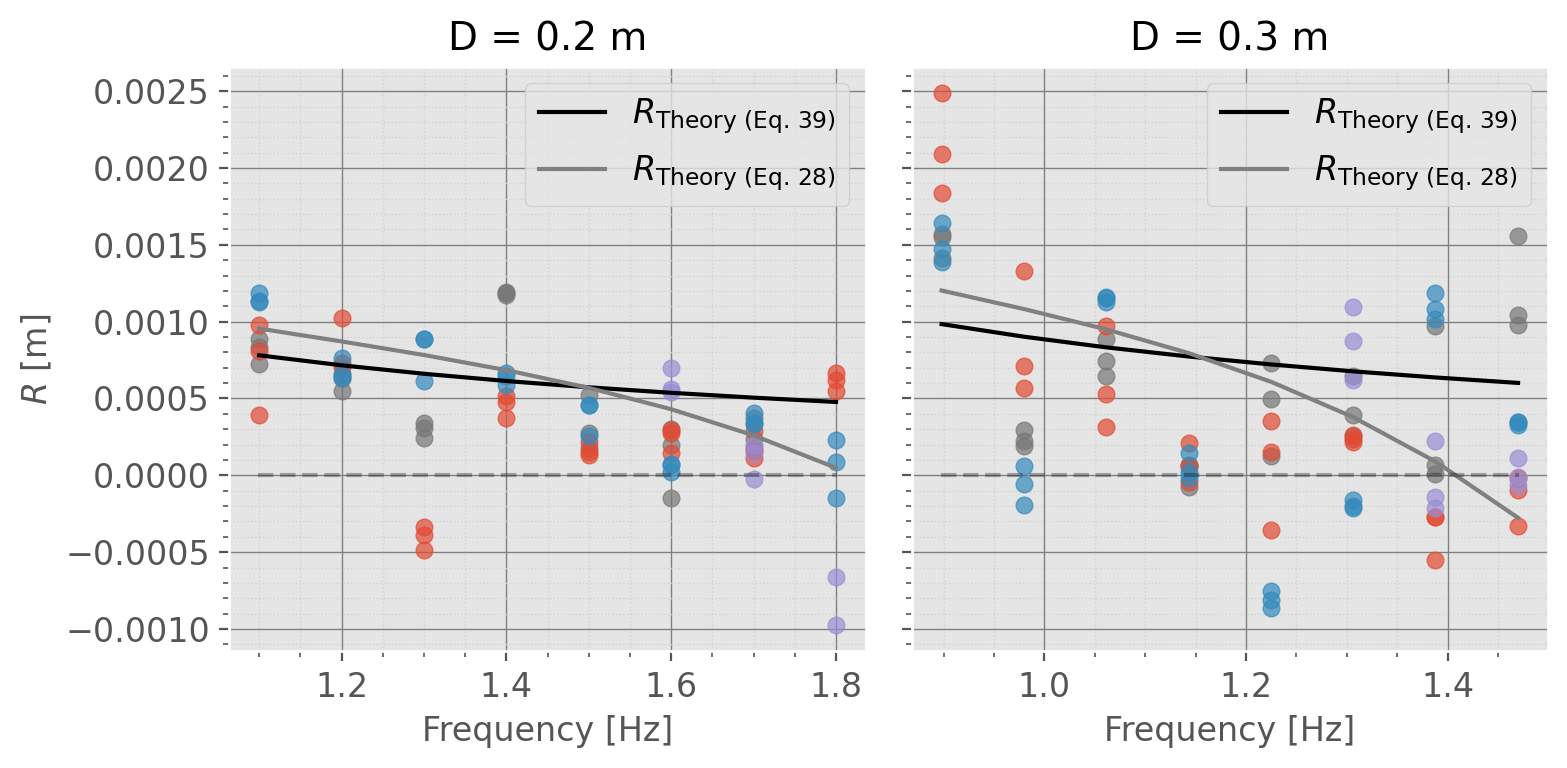

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["frequency"], sub["R_plates"],
               marker='o',
               alpha=0.7,
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["frequency"], sub["R_plates"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))

ax[0].plot(f_20, R_theory_20_eq39, '-', color='black', label=r'$R_{\text{Theory (Eq. 39)}}$')
ax[1].plot(f_30, R_theory_30_eq39, '-', color='black', label=r'$R_{\text{Theory (Eq. 39)}}$')

ax[0].plot(f_20, R_theory_20_eq28, '-', color='gray', label=r'$R_{\text{Theory (Eq. 28)}}$')
ax[1].plot(f_30, R_theory_30_eq28, '-', color='gray', label=r'$R_{\text{Theory (Eq. 28)}}$')

ax[0].hlines(0, 1.099, 1.801, colors='k', linestyles='dashed', alpha=0.3)
ax[1].hlines(0, 0.897, 1.471, colors='k', linestyles='dashed', alpha=0.3)

ax[0].set_title('D = 0.2 m')
ax[1].set_title('D = 0.3 m')

ax[0].set_xlabel('Frequency [Hz]')
ax[1].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'$R$ [m]')
ax[0].legend(loc='upper right')
ax[1].legend(loc='upper right')

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray') 

plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/R_obs_vs_theory.png", dpi=300)

In [64]:
# RMS of the difference between observed and theoretical damping coefficients
rms_20_eq39 = []
for idx, f in enumerate(f_20):
    obs = plates_20.loc[plates_20['frequency'] == f, 'R_plates'].values
    for val in obs:
        rms_20_eq39.append(np.sqrt((val - R_theory_20_eq39[idx]) ** 2))
plates_20['rms_R_eq39'] = rms_20_eq39

rms_30_eq39 = []
for idx, f in enumerate(f_30):
    obs = plates_30.loc[plates_30['frequency'] == f, 'R_plates'].values
    for val in obs:
        rms_30_eq39.append(np.sqrt((val - R_theory_30_eq39[idx]) ** 2))
plates_30['rms_R_eq39'] = rms_30_eq39

In [65]:
# RMS of the difference between observed and theoretical damping coefficients
rms_20_eq28 = []
for idx, f in enumerate(f_20):
    obs = plates_20.loc[plates_20['frequency'] == f, 'R_plates'].values
    for val in obs:
        rms_20_eq28.append(np.sqrt((val - R_theory_20_eq28[idx]) ** 2))
plates_20['rms_R_eq28'] = rms_20_eq28

rms_30_eq28 = []
for idx, f in enumerate(f_30):
    obs = plates_30.loc[plates_30['frequency'] == f, 'R_plates'].values
    for val in obs:
        rms_30_eq28.append(np.sqrt((val - R_theory_30_eq28[idx]) ** 2))
plates_30['rms_R_eq28'] = rms_30_eq28

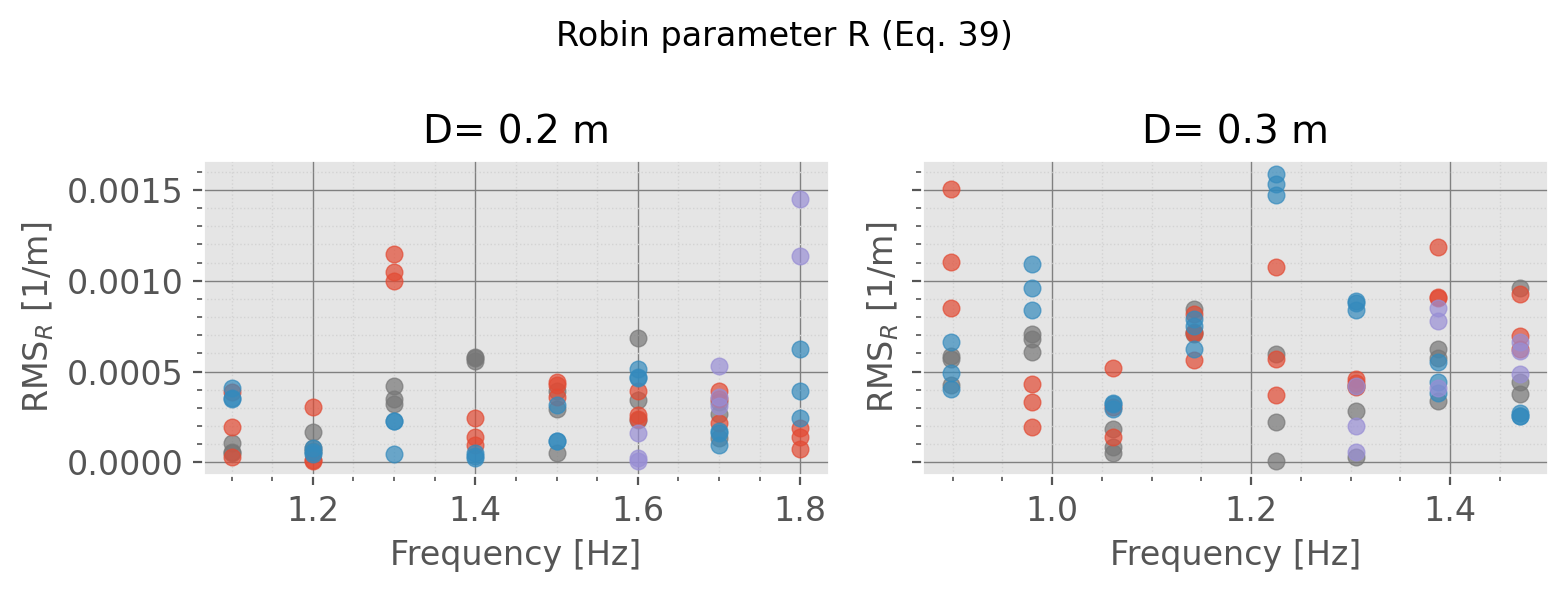

In [66]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["frequency"], sub["rms_R_eq39"],
               marker='o',
               alpha=0.7,
               label=f'{level}',
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["frequency"], sub["rms_R_eq39"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))

ax[0].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'RMS$_{R}$ [1/m]')
ax[0].set_title("D= 0.2 m")
ax[1].set_xlabel('Frequency [Hz]')
ax[1].set_ylabel(r'RMS$_{R}$ [1/m]')
ax[1].set_title("D= 0.3 m")
ax[1].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'RMS$_{R}$ [1/m]')
ax[0].set_title("D= 0.2 m")
ax[1].set_xlabel('Frequency [Hz]')
ax[1].set_ylabel(r'RMS$_{R}$ [1/m]')
ax[1].set_title("D= 0.3 m")

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray')
fig.suptitle("Robin parameter R (Eq. 39)", fontsize=12)
plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/rms_R_obs_vs_theory_eq39.png", dpi=300)

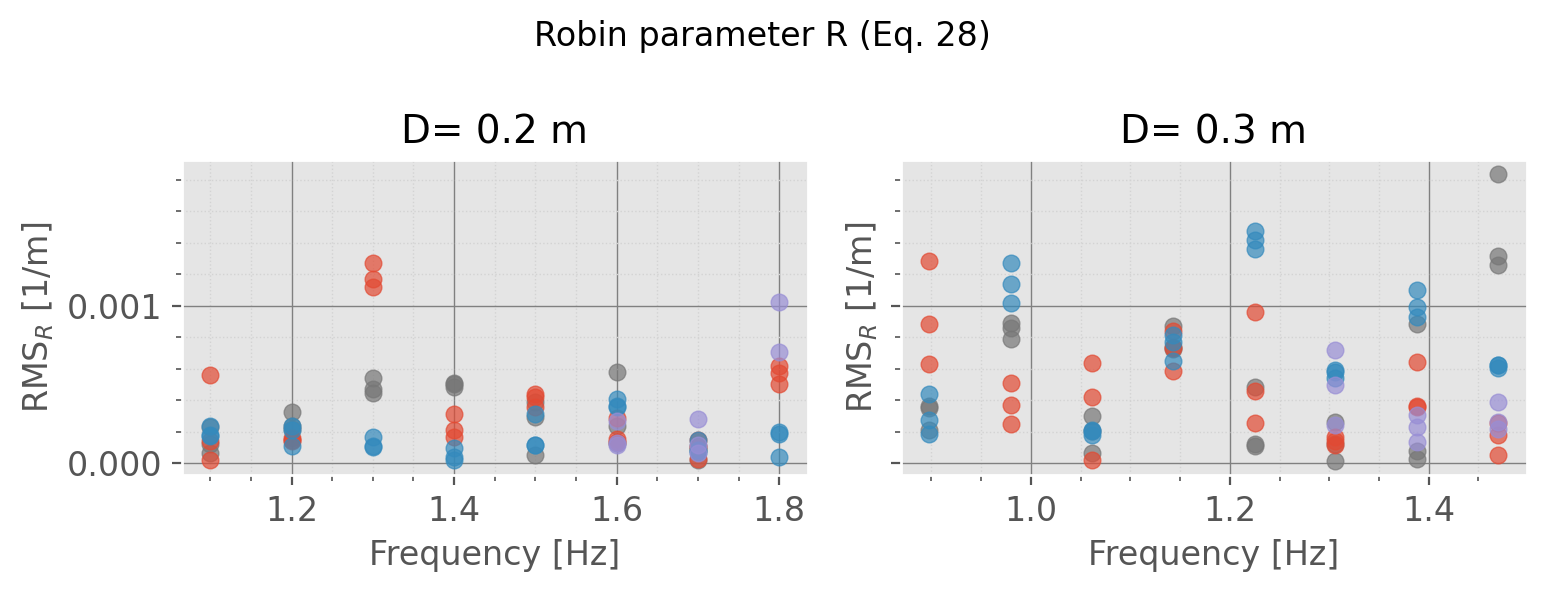

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["frequency"], sub["rms_R_eq28"],
               marker='o',
               alpha=0.7,
               label=f'{level}',
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["frequency"], sub["rms_R_eq28"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))

ax[0].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'RMS$_{R}$ [1/m]')
ax[0].set_title("D= 0.2 m")
ax[1].set_xlabel('Frequency [Hz]')
ax[1].set_ylabel(r'RMS$_{R}$ [1/m]')
ax[1].set_title("D= 0.3 m")
ax[1].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'RMS$_{R}$ [1/m]')
ax[0].set_title("D= 0.2 m")
ax[1].set_xlabel('Frequency [Hz]')
ax[1].set_ylabel(r'RMS$_{R}$ [1/m]')
ax[1].set_title("D= 0.3 m")

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray')
    
fig.suptitle("Robin parameter R (Eq. 28)", fontsize=12)
plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/rms_R_obs_vs_theory_eq28.png", dpi=300)